# Solution: Drinking Water Demand Forecasting with Recurrent Neural Networks - Part 3
## Multi-step ahead prediction with Gated Recurrent Neural Networks

In Part 3, we will build upon the **multi-step ahead prediction** done in Part 2 with simple Recurrent Neural Networks (RNNs).

The focus now is on training *gated RNNs* such as **Long Short-Term Memory** and **Gater Recurrent Unit** RNNs for water demand forecasting up to 24 hours ahead.

## Assignments

1. **Gated RNNs for recursive prediction**
  - Select either [LSTM](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html) or [GRU](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html). You can pair up with a fellow student so that each of you looks at a different model implementation.
  - Train the gated RNN for one-step ahead prediction
  - Implement the recursive prediction task of Part 2 to predict up to 24 steps ahead.
  - Critically analyze the performance differences between the gated RNN of your choice and previous architectures. Which model yielded better results? Discuss the reasons for this performance difference.

2. **Develop Gated RNNs for 24-steps ahead forecasting**
  - Extend the LSTM or GRU model of point 1 for 24-steps ahead prediction.
  - Minimal changes to the existing implementations are required:
    - Make sure `output_size=24`;
    - Remember, `evaluate_model_multistep` will not work!
  - Discuss the results, also by comparing them against the recursive approach of point 1 and what you obtained with MLP and simple RNN.

3. **Develop an Encoder-Decoder gated RNN model for 24-steps ahead forecasting**
  - Adapt the LSTM or GRU model to an encoder-decoder framework for producing the 24-steps ahead forecasts.
    - Encoder Modifications: Retain the basic structure of the class. As you have seen for the RNN case, the hidden states `hn` capture the *context*.
    - Decoder Design: In the decoder, use the context in the final hidden state from the encoder as the initial state. Generate the forecast sequence step by step.
    - <u>If you are using an LSTM</u>, you can also initialize the decoder `cell` state with the last `cell` state of the encoder, like you initialize the hidden states.
  - After trying a few version of this architecture and tweaking some hyperparameters, discuss whether the encoder-decoder better captures the temporal relationships.

## Solutions

### Setup (you can safely skip this for the solution)
We will reuse the setup scripts from part 1 & part 2 of the Notebook series. This part of the solutions can be skipped.


In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time
import os
from urllib.request import urlretrieve

from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

In [87]:
# Check if CUDA is available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


We now download the data, then load it into a dataframe.

In [ ]:
# Download the water demand dataset
year_1 = "https://surfdrive.surf.nl/files/index.php/s/T2SN8dnXXYWz4q5/download"
year_2 = "https://surfdrive.surf.nl/files/index.php/s/StRwCboQoDPRGdD/download"

data_folder = "data"
water_demand_file1 = os.path.join(data_folder, "water_demand_Y1.txt")
water_demand_file2 = os.path.join(data_folder, "water_demand_Y2.txt")

if not os.path.isfile(water_demand_file1):
    print("Downloading dataset...")
    os.makedirs("data", exist_ok=True)
    urlretrieve(year_1, water_demand_file1)
    urlretrieve(year_2, water_demand_file2)

In [89]:
df = pd.read_csv(water_demand_file1,header=None, sep=r"\s+")

The following create_sequences and scale_sequences methods are explained in Part 1 of this Notebook series.

In [90]:
def create_sequences(series,T=168,H=24):
    # This function creates a dataset of input/output sequences from a time series.
    # The input sequence is T steps long, from time t to time t+T (excluded).
    # The output sequence is H steps long, from time t+T to time t+T+H (excluded).
    X = []
    Y = []
    for t in range(len(series)-T-H):
        x = series[t:t+T]
        X.append(x)
        y = series[t+T:t+T+H]
        Y.append(y)
    X = np.array(X)
    Y = np.array(Y)
    return X,Y

def scale_sequences(X,scaler=None,scaler_type='standard'):
    # Uses a standard scaler to transform sequences. The scaler is created if no scaler is passed as argument.
    Xshape=X.shape
    if scaler:
        X = scaler.transform(X.reshape(-1,1)).reshape(Xshape)
        return X
    else:
        if scaler_type == 'standard':
            scaler = StandardScaler()
        elif scaler_type == 'minmax':
            scaler = MinMaxScaler()
        else:
            raise Exception("Type of scikit-learn scaler not supported. Choose 'standard' or 'minmax.")
        X = scaler.fit_transform(X.reshape(-1,1)).reshape(Xshape)
        return X, scaler

We now create our input sequences, starting off with a single prediction time step (we will later change this to 24!)

In [91]:
T = 168     # number of time steps to use for prediction (168 hours = 1 week)
H = 1       # number of time steps to predict (1 hour)
X, Y = create_sequences(df.values.reshape(-1),T=T,H=H)
print(X.shape)
print(Y.shape)

(8591, 168)
(8591, 1)


To verify everything loaded in properly, we can display a sample input-output pair.

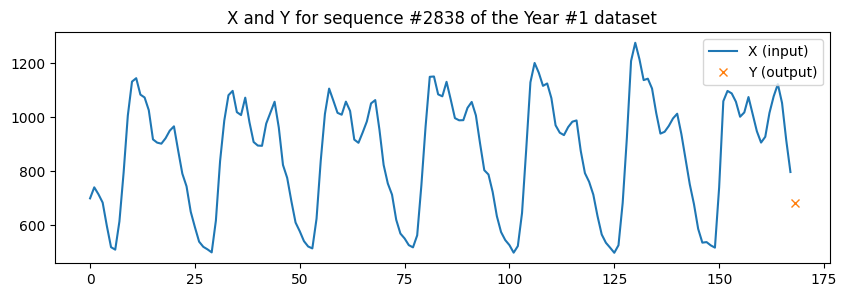

In [92]:
random_ix = np.random.choice(X.shape[0])
f, ax = plt.subplots(1,figsize=(10,3))
ax.plot(np.arange(T),X[0], label='X (input)')
ax.plot(np.arange(T,T+H),Y[0], 'x', label = 'Y (output)')
ax.set_title(f'X and Y for sequence #{random_ix} of the Year #1 dataset');
ax.legend();

Since everything works, we now create our training, test, and validation sets.

In [93]:
# We keep track of indexes of train and validation.
X_tra, X_tst, Y_tra, Y_tst, ix_tra, ix_tst = train_test_split(
    X, Y, np.arange(X.shape[0]), test_size=0.30, shuffle=True, random_state=42)

# Split the existing test dataset into validation and test sets (50/50 split)
X_val, X_tst, Y_val, Y_tst, ix_val, ix_tst = train_test_split(
    X_tst, Y_tst, ix_tst, test_size=0.5, shuffle=True, random_state=42)


print(f"X_tra.shape: {X_tra.shape}, Y_tra.shape: {Y_tra.shape}")
print(f"X_val.shape: {X_val.shape}, Y_val.shape: {Y_val.shape}")
print(f"X_tst.shape: {X_tst.shape}, Y_tst.shape: {Y_tst.shape}")

X_tra.shape: (6013, 168), Y_tra.shape: (6013, 1)
X_val.shape: (1289, 168), Y_val.shape: (1289, 1)
X_tst.shape: (1289, 168), Y_tst.shape: (1289, 1)


In [94]:
# scale/normalize
X_tra, scaler = scale_sequences(X_tra, scaler_type='standard')
Y_tra = scale_sequences(Y_tra, scaler)
X_val = scale_sequences(X_val, scaler)
Y_val = scale_sequences(Y_val, scaler)
X_tst = scale_sequences(X_tst, scaler)
Y_tst = scale_sequences(Y_tst, scaler)

Now that we have create our scaled data sets for training, validating, and testing, we can move on to defining our evaluation function.

In [95]:
def evaluate_model(model, test_loader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    test_loss = 0

    with torch.no_grad():  # No need to track gradients during evaluation
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)
    return avg_test_loss

def train_and_validate(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, save_path, echo_iter = 20):
    best_val_loss = float("inf")  # Track the best validation loss
    train_losses = []
    val_losses = []

    start_time = time.time()  # Start training time

    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        total_train_loss = 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation Phase
        avg_val_loss = evaluate_model(model, val_loader, criterion, device)
        val_losses.append(avg_val_loss)

        # Save Best Model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)

        if echo_iter > 0:
            if (epoch + 1) % echo_iter == 0:
                print(f'Epoch {epoch+1}/{num_epochs}', f'Train Loss: {avg_train_loss:.4f}, '
                      f'Validation Loss: {avg_val_loss:.4f}', f'Best Validation Loss: {best_val_loss:.4f}')

    train_time = time.time() - start_time
    if echo_iter > 0:
        print("Training complete.")
    return train_losses, val_losses, best_val_loss, train_time

We will finally create our tensor datasets and loaders for the datasets.

In [96]:
train_dataset = TensorDataset(torch.tensor(X_tra, dtype=torch.float32), torch.tensor(Y_tra, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(Y_val, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_tst, dtype=torch.float32), torch.tensor(Y_tst, dtype=torch.float32 ))

In [97]:
batch_size = 256      # You can modify this based on your requirements

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

We are now ready to go!

### Assignment 1 - Gated RNNs
In this solution, we will explore the LSTM model. Here we defined our own model class where we have the LSTM layer and a fully connected layer to get our desired output. Note that this is a very simple LSTM, and we will later explore varations, with a focus on getting 24-step forecasting.

In [98]:
class LSTMModel(nn.Module):
    def __init__(self, hidden_size, num_layers, output_size):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Reshape input to have feature dimension of 1
        x = x.unsqueeze(-1)   # Assuming input x has shape (batch, sequence)

        # Forward pass through the LSTM layer
        x, _ = self.lstm(x)

        # Take the output from the last time step
        x = x[:, -1, :]

        # Pass the output through the fully connected layer
        x = self.fc(x)

        return x

#### 1 Step Forecasting
We can now instantiate our model, and we will train it for 200 epochs. For the purpose of this solution, we will go for one layer in the LSTM, but feel free to experiment with this. There are many possibilities to improve the model. Furthermore, we will start off with predicting just one step ahead, and later use recursively predict 24.

In [99]:
model_LSTM = LSTMModel(128, 1, H).to(device)

In [100]:
num_epochs = 200
lr = 0.0005


In [101]:
# Loss function
criterion = nn.MSELoss()  # Or another appropriate loss function

optimizer = optim.AdamW(model_LSTM.parameters(), lr=lr)
save_path_LSTM = 'LSTM_model.pth'

In [102]:
train_losses_LSTM, val_losses_LSTM, best_val_loss_LSTM, time_LSTM = train_and_validate(model_LSTM, train_loader, val_loader, criterion, optimizer, num_epochs, device, save_path_LSTM)

Epoch 20/200 Train Loss: 0.0903, Validation Loss: 0.0921 Best Validation Loss: 0.0921
Epoch 40/200 Train Loss: 0.1461, Validation Loss: 0.1385 Best Validation Loss: 0.0740
Epoch 60/200 Train Loss: 0.0637, Validation Loss: 0.0809 Best Validation Loss: 0.0740
Epoch 80/200 Train Loss: 0.0414, Validation Loss: 0.0567 Best Validation Loss: 0.0567
Epoch 100/200 Train Loss: 0.0348, Validation Loss: 0.0406 Best Validation Loss: 0.0406
Epoch 120/200 Train Loss: 0.0257, Validation Loss: 0.0359 Best Validation Loss: 0.0310
Epoch 140/200 Train Loss: 0.0220, Validation Loss: 0.0284 Best Validation Loss: 0.0272
Epoch 160/200 Train Loss: 0.0209, Validation Loss: 0.0278 Best Validation Loss: 0.0243
Epoch 180/200 Train Loss: 0.0183, Validation Loss: 0.0231 Best Validation Loss: 0.0214
Epoch 200/200 Train Loss: 0.0209, Validation Loss: 0.0276 Best Validation Loss: 0.0193
Training complete.


We have train our first LSTM. Now, let's investigate how it performs. First, we can display its training and validation losses during training.

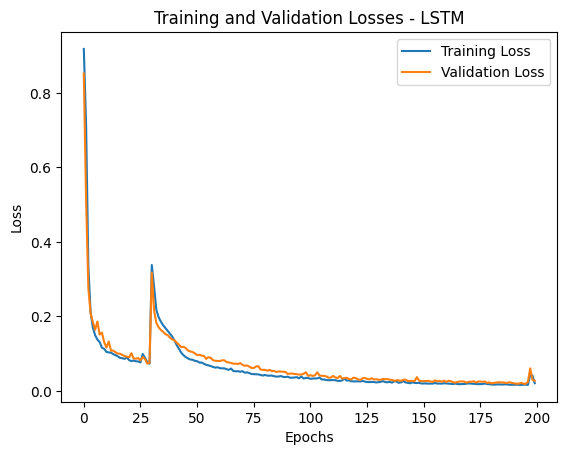

In [103]:
plt.plot(train_losses_LSTM, label='Training Loss')
plt.plot(val_losses_LSTM, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses - LSTM')
plt.legend()
plt.show()

It is also worth inspecting some important attributes of our model, such as the trainable parameters, and other metrics.

In [104]:
# Load the best model
model_LSTM.load_state_dict(torch.load(save_path_LSTM))

<All keys matched successfully>

In [105]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

avg_test_loss_LSTM = evaluate_model(model_LSTM, test_loader, criterion, device)

print(f"MLP --> num. trainable parameters:{count_parameters(model_LSTM):8d} | Best Val Loss: {best_val_loss_LSTM:.4f} | Test loss: {avg_test_loss_LSTM:.4f} | Training time: {time_LSTM:.2f}")

MLP --> num. trainable parameters:   67201 | Best Val Loss: 0.0193 | Test loss: 0.0144 | Training time: 83.14


Let's see how our model performs by displaying some sample test results. We can see that the model performs relatively well, and you can compare this with the plots form Part 1 and Part 2 to investigate the differences.

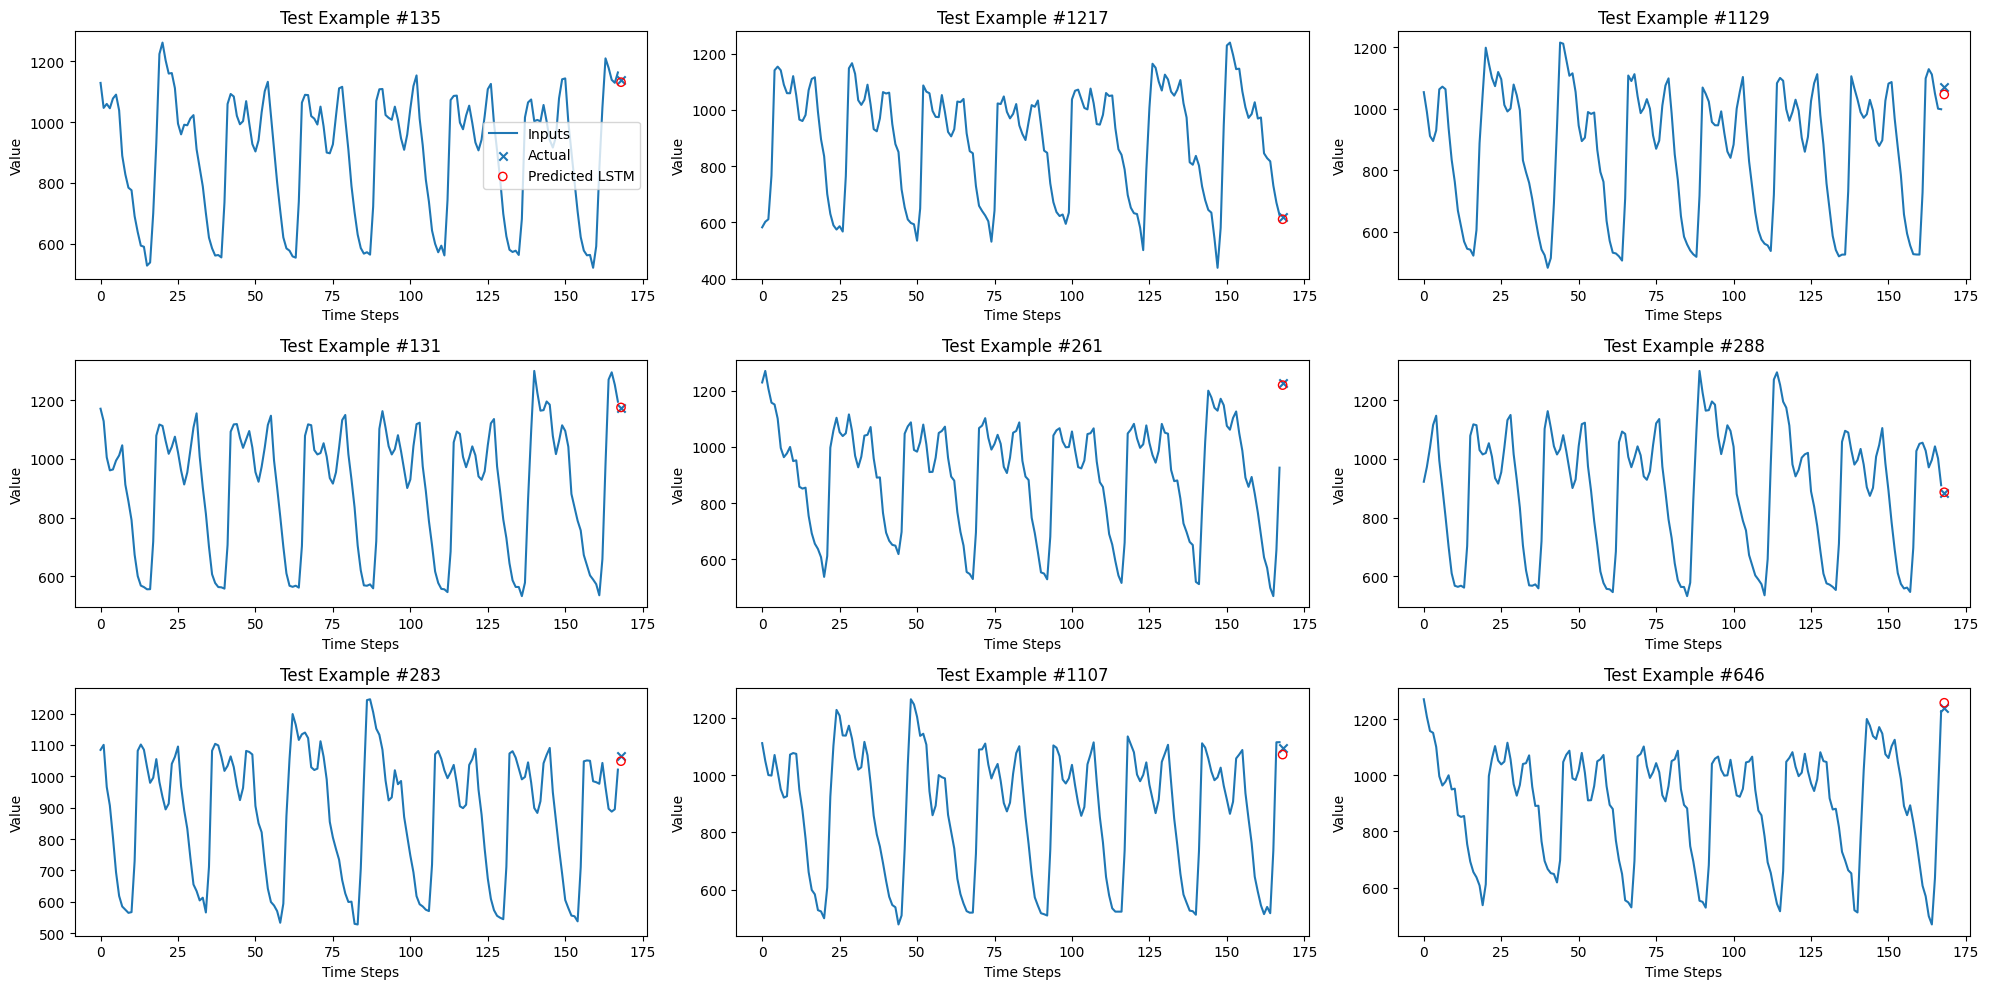

In [106]:
model_LSTM.eval()

def drawTestPlotsGivenModel(model, showInputs=True):
  f,axes = plt.subplots(3,3, figsize=(20,10))

  for ix, ax in enumerate(axes.reshape(-1)):
    with torch.no_grad():
        # Randomly select a sample from the test dataset
        random_index = random.randint(0, len(test_dataset) - 1)
        inputs, target = test_dataset[random_index]
        inputs, target = inputs.to(device).unsqueeze(0), target.to(device).unsqueeze(0)

        # Predict
        prediction_LSTM = model(inputs)

        # Rescale inputs, target, and prediction using the scaler
        inputs_rescaled = scaler.inverse_transform(inputs.cpu().numpy().flatten().reshape(-1, 1)).flatten()
        target_rescaled = scaler.inverse_transform(target.cpu().numpy().flatten().reshape(-1, 1)).flatten()
        prediction_rescaled = scaler.inverse_transform(prediction_LSTM.cpu().numpy().flatten().reshape(-1, 1)).flatten()

        # Plotting inputs (time series)
        if (showInputs):
          ax.plot(np.arange(T), inputs_rescaled, label='Inputs')

        # Plotting prediction vs target
        ax.scatter(np.arange(T, T+H), target_rescaled, marker='x', label='Actual')
        ax.scatter(np.arange(T, T+H), prediction_rescaled, marker='o', facecolors='none', edgecolors='r', label='Predicted LSTM')

        ax.set_title(f'Test Example #{random_index}')
        ax.set_xlabel('Time Steps')
        ax.set_ylabel('Value')
        if ix == 0:
          ax.legend()

  f.tight_layout()

drawTestPlotsGivenModel(model_LSTM)

#### Recursive Forecasting for 24 Steps
We will now predict the next 24 steps by recursively predicting the next values. Just like with Part 2, pay close attention to the performance difference between this and predicting the 24 steps concurrently.

We will start off by loading in the data for 24 steps and displaying one such input-output pair to see what our model will be predicting exactly.

In [107]:
T = 168     # number of time steps to use for prediction (168 hours = 1 week)
H = 24       # number of time steps to predict (24 hours/ 1 day)
X, Y = create_sequences(df.values.reshape(-1),T=T,H=H)
print(X.shape)
print(Y.shape)

(8568, 168)
(8568, 24)


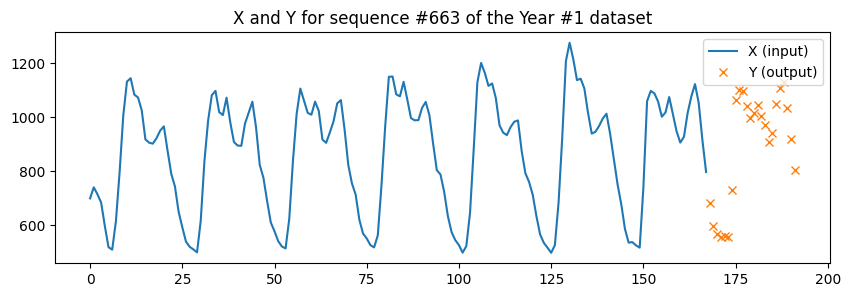

In [108]:
random_ix = np.random.choice(X.shape[0])
f, ax = plt.subplots(1,figsize=(10,3))
ax.plot(np.arange(T),X[0], label='X (input)')
ax.plot(np.arange(T,T+H),Y[0], 'x', label = 'Y (output)')
ax.set_title(f'X and Y for sequence #{random_ix} of the Year #1 dataset');
ax.legend();

We will now create our datasets and scale them for the 24 step forecasting data.

In [109]:
# We keep track of indexes of train and validation.
X_tra, X_tst, Y_tra, Y_tst, ix_tra, ix_tst = train_test_split(
    X, Y, np.arange(X.shape[0]), test_size=0.30, shuffle=True, random_state=42)

# Split the existing test dataset into validation and test sets (50/50 split)
X_val, X_tst, Y_val, Y_tst, ix_val, ix_tst = train_test_split(
    X_tst, Y_tst, ix_tst, test_size=0.5, shuffle=True, random_state=42)


print(f"X_tra.shape: {X_tra.shape}, Y_tra.shape: {Y_tra.shape}")
print(f"X_val.shape: {X_val.shape}, Y_val.shape: {Y_val.shape}")
print(f"X_tst.shape: {X_tst.shape}, Y_tst.shape: {Y_tst.shape}")

X_tra.shape: (5997, 168), Y_tra.shape: (5997, 24)
X_val.shape: (1285, 168), Y_val.shape: (1285, 24)
X_tst.shape: (1286, 168), Y_tst.shape: (1286, 24)


In [110]:
# scale/normalize
X_tra, scaler = scale_sequences(X_tra, scaler_type='standard')
Y_tra = scale_sequences(Y_tra, scaler)
X_val = scale_sequences(X_val, scaler)
Y_val = scale_sequences(Y_val, scaler)
X_tst = scale_sequences(X_tst, scaler)
Y_tst = scale_sequences(Y_tst, scaler)

And lastly, we will create our tensor datasets and train loaders for this new task.

In [111]:
train_dataset = TensorDataset(torch.tensor(X_tra, dtype=torch.float32), torch.tensor(Y_tra, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(Y_val, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_tst, dtype=torch.float32), torch.tensor(Y_tst, dtype=torch.float32 ))

In [112]:
batch_size = 256      # You can modify this based on your requirements

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

The following _evaluate_model_multistep_ method is the same as from Part 2. Refer back to the Part 2 notebook for a better explanation and documentation of what it does. For our purposes, we will be using it to recursively forecast the next 24 steps using our LSTM that has a single out of one step at a time.

In [113]:
def evaluate_model_multistep(model, test_loader, criterion, device, T, H):
    model.eval()  # Set the model to evaluation mode
    test_loss = 0

    all_predictions = []  # List to store all batch predictions
    all_targets = []      # List to store all batch targets

    with torch.no_grad():  # No need to track gradients during evaluation
        for initial_inputs, initial_targets in test_loader:
            step_inputs = initial_inputs.to(device)
            targets = initial_targets.to(device)

            # Holds predictions for comparison with targets
            predictions = []

            # Iterate for H steps
            for h in range(H):
                outputs = model(step_inputs)
                predictions.append(outputs)

                # Reshape or expand outputs to be 3D: [batch_size, 1, features]
                next_input = outputs.unsqueeze(-1).squeeze(1)  # Adjust the dimensions as necessary

                # Update step_inputs by sliding the window: remove the oldest input and add the new output
                # Ensure that step_inputs and next_input are correctly shaped for concatenation
                step_inputs = torch.cat((step_inputs[:, 1:], next_input), dim=1)

            # Concatenate predictions and calculate loss against the entire target sequence
            batch_predictions  = torch.stack(predictions, dim=1).squeeze(-1)  # Squeeze the last dimension

            loss = criterion(batch_predictions , targets)
            test_loss += loss.item()

            # Store batch predictions and targets
            all_predictions.append(batch_predictions.cpu())
            all_targets.append(targets.cpu())

    # Concatenate all batch predictions and targets into tensors
    all_predictions = torch.cat(all_predictions, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    avg_test_loss = test_loss / len(test_loader)
    return avg_test_loss, all_predictions, all_targets

We now evaluate our model recursively and compare it to the test loader with 24-step predictions.

In [114]:
criterion = nn.MSELoss()  # Or another appropriate loss function

avg_test_loss_LSTM, predictions_LSTM, targets = evaluate_model_multistep(model_LSTM, test_loader, criterion, device, T, H)

Lets define a function to display these results called _drawTestPlots_ and use it to compare our different models for the 24-step forecasting problem. We begin by displaying the results of our recursive approach.

In [115]:
def drawTestPlots(predictions):
  # Create subplots
  f, axes = plt.subplots(2, 4, figsize=(20, 8))

  for ix,ax in enumerate(axes.reshape(-1)):
      random_index = random.randint(0, len(targets) - 1)
      # Rescaling targets and predictions
      target_rescaled = scaler.inverse_transform(targets[random_index].cpu().numpy().flatten().reshape(-1, 1)).flatten()
      prediction_LSTM_rescaled = scaler.inverse_transform(predictions[random_index].cpu().numpy().flatten().reshape(-1, 1)).flatten()

      # Plotting prediction vs target
      ax.scatter(np.arange(T, T+H), target_rescaled, marker='x', label='Actual')
      ax.scatter(np.arange(T, T+H), prediction_LSTM_rescaled, marker='o', facecolors='none', edgecolors='r', label='Predicted LSTM')

      ax.set_title(f'Test Example #{random_index}')
      ax.set_xlabel('Time Steps')
      ax.set_ylabel('Value')
      if ix == 0:
          ax.legend()

  f.tight_layout()

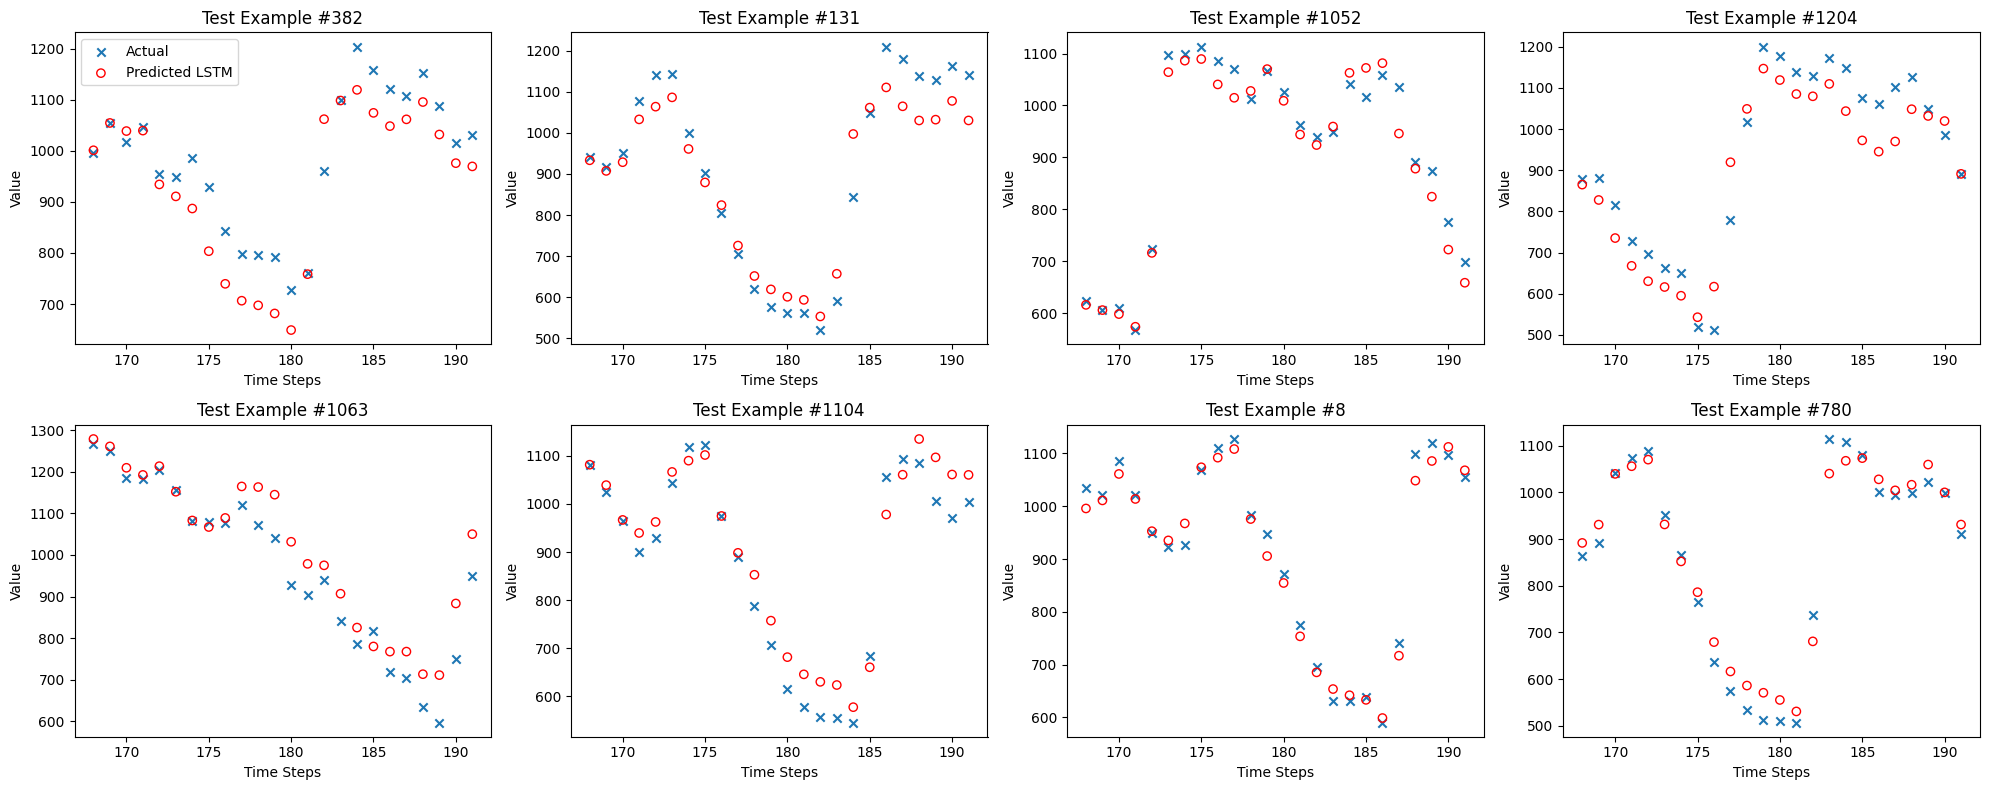

In [116]:
drawTestPlots(predictions_LSTM)

We can compare these results to the forecasting in Part 2. The results showcase the power of LSTMs, and specifically their ability to circumvent the vanishing and exploding gradient problems.

### Assignment 2 - 24-Steps Ahead Forecasting (concurrently)
We will now adapt our output size to predict 24 steps concurrently.

In [117]:
model_LSTM_24_steps = LSTMModel(128, 2, H).to(device)

In [118]:
# Loss function
criterion = nn.MSELoss()  # Or another appropriate loss function

optimizer = optim.AdamW(model_LSTM_24_steps.parameters(), lr=lr)
save_path_LSTM_24_steps = 'LSTM_model_24_steps.pth'

In [119]:
train_losses_LSTM_24_steps, val_losses_LSTM_24_steps, best_val_loss_LSTM_24_steps, time_LSTM_24_steps = train_and_validate(model_LSTM_24_steps, train_loader, val_loader, criterion, optimizer, num_epochs, device, save_path_LSTM_24_steps)

Epoch 20/200 Train Loss: 0.0987, Validation Loss: 0.1059 Best Validation Loss: 0.1059
Epoch 40/200 Train Loss: 0.0803, Validation Loss: 0.0973 Best Validation Loss: 0.0962
Epoch 60/200 Train Loss: 0.0599, Validation Loss: 0.0681 Best Validation Loss: 0.0681
Epoch 80/200 Train Loss: 0.0452, Validation Loss: 0.0560 Best Validation Loss: 0.0549
Epoch 100/200 Train Loss: 0.0353, Validation Loss: 0.0494 Best Validation Loss: 0.0402
Epoch 120/200 Train Loss: 0.0277, Validation Loss: 0.0311 Best Validation Loss: 0.0311
Epoch 140/200 Train Loss: 0.0245, Validation Loss: 0.0278 Best Validation Loss: 0.0277
Epoch 160/200 Train Loss: 0.0222, Validation Loss: 0.0266 Best Validation Loss: 0.0262
Epoch 180/200 Train Loss: 0.0207, Validation Loss: 0.0263 Best Validation Loss: 0.0251
Epoch 200/200 Train Loss: 0.0207, Validation Loss: 0.0254 Best Validation Loss: 0.0246
Training complete.


In [120]:
# Load the best model
model_LSTM_24_steps.load_state_dict(torch.load(save_path_LSTM_24_steps))

<All keys matched successfully>

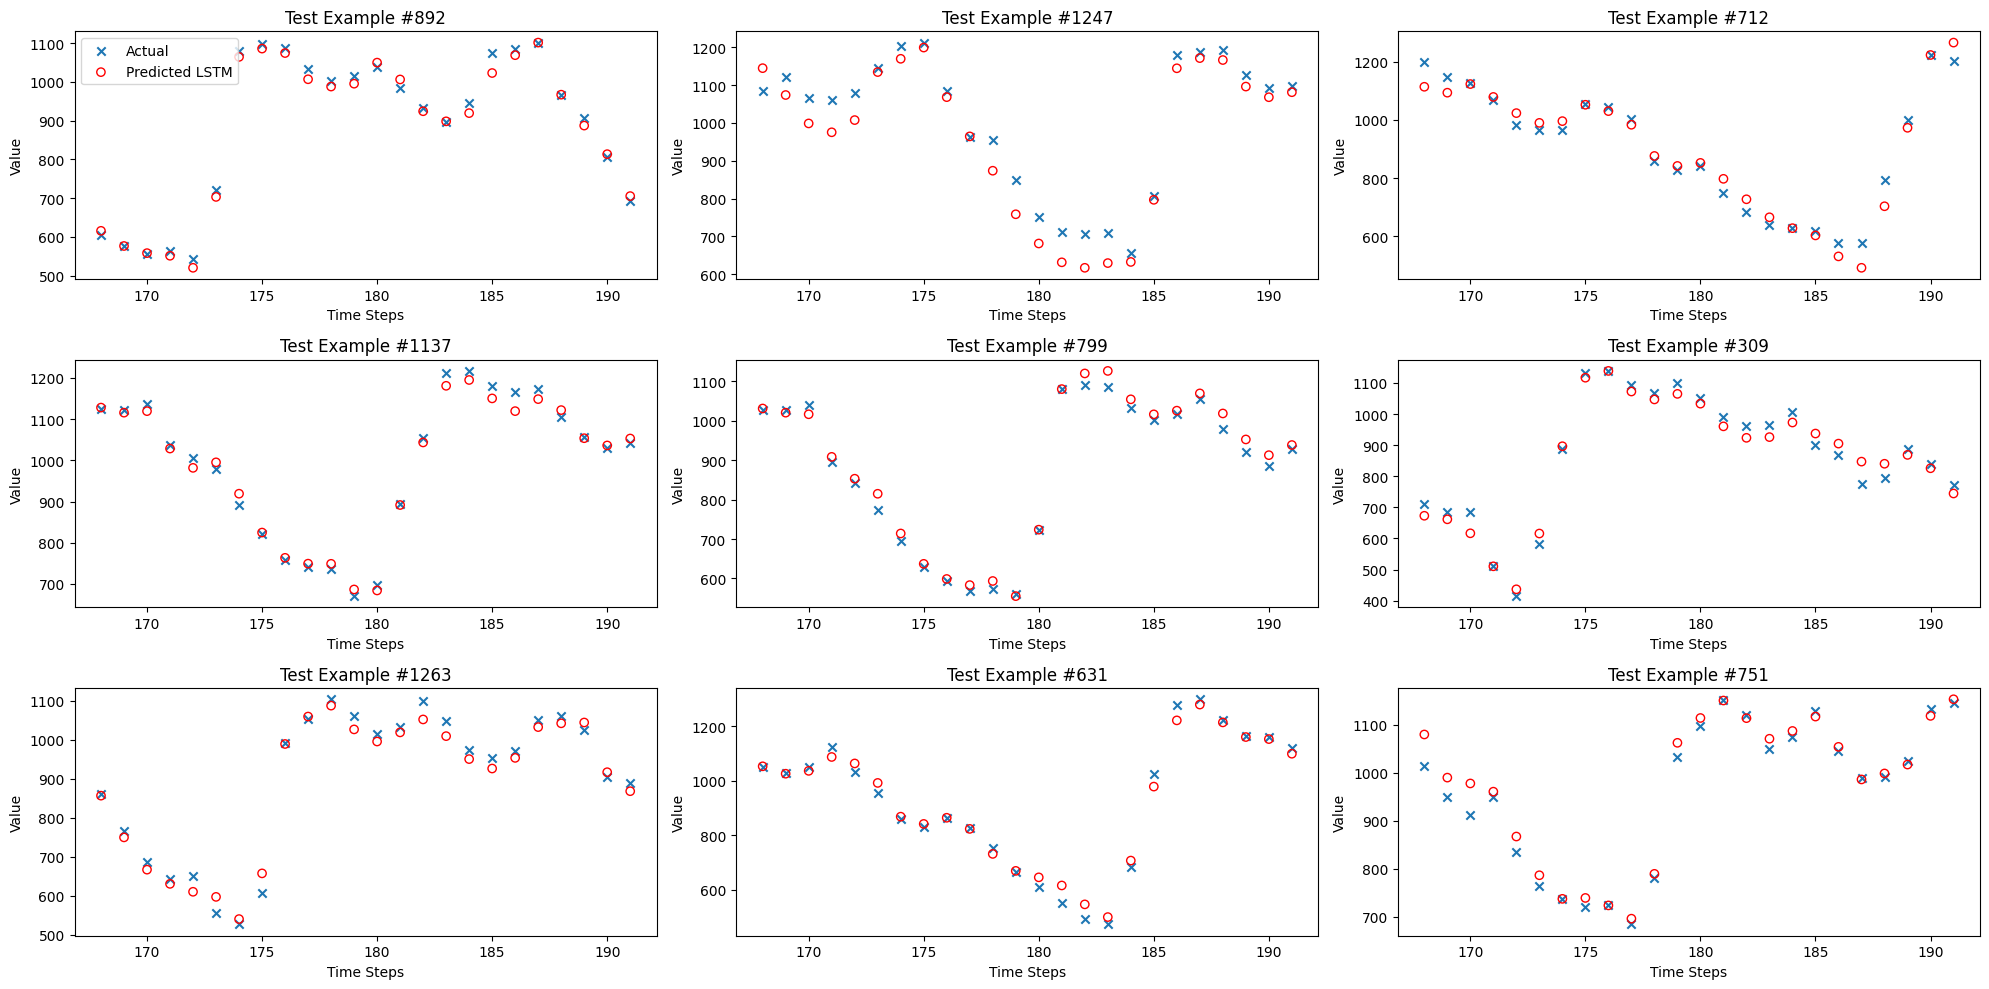

In [121]:
model_LSTM_24_steps.eval()
drawTestPlotsGivenModel(model_LSTM_24_steps, False)

### Assignment 3 - Decoder-Encoder Framework
We will now adapt our model and make it more powerful by modifying it to the encoder-decoder framework. The process is similar to the encoder-decoder framework in Part 2.

In [122]:
class EncoderDecoderLSTM(nn.Module):
    def __init__(self, hidden_size, output_length, num_layers=1):
        super(EncoderDecoderLSTM, self).__init__()

        # Encoder LSTM layer
        self.encoder_lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)

        # Decoder LSTM layer
        # For simplicity, the decoder will have the same number of layers and hidden size
        self.decoder_lstm = nn.LSTM(input_size = hidden_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)

        # Output layer
        self.fc = nn.Linear(hidden_size, 1)

        # Store output size, needed for the decoding
        self.output_length = output_length

    def forward(self, x):
        # Encoder
        # Reshape input to have feature dimension equal to input_size
        # Assuming input x has shape (batch, sequence_length, input_size)
        # print(x.size())
        x = x.unsqueeze(-1)

        _ , context = self.encoder_lstm(x)   # Context is the last hidden state from the encoder
        context_hidden, _ = context  # Extract the hidden state from the tuple

        # Decoder
        decoder_input = context_hidden.repeat(self.output_length, 1, 1).permute(1, 0, 2)
        decoder_output, _ = self.decoder_lstm(decoder_input, context)

        # Combine outputs of all units for each time step with the shared fc; reshape and squeeze to match target data for loss computation.
        output = self.fc(decoder_output).permute(0, 2, 1).squeeze()

        return output


We can now instantiate our improved encoder-decoder framework LSTM model and train it to be able to compare it to the previous models.

In [123]:
model_encoder_decoder_lstm = EncoderDecoderLSTM(128, H, num_layers=1).to(device)

In [124]:
# Loss function
criterion = nn.MSELoss()  # Or another appropriate loss function

optimizer = optim.AdamW(model_encoder_decoder_lstm.parameters(), lr=lr)
save_path_encoder_decoder_lstm = 'LSTM_model_encoder_decoder.pth'

In [125]:
train_losses_LSTM_enc_dec, val_losses_LSTM_enc_dec, best_val_loss_LSTM_enc_dec, time_LSTM_enc_dec = train_and_validate(model_encoder_decoder_lstm, train_loader, val_loader, criterion, optimizer, num_epochs, device, save_path_encoder_decoder_lstm)

Epoch 20/200 Train Loss: 0.0998, Validation Loss: 0.1053 Best Validation Loss: 0.1053
Epoch 40/200 Train Loss: 0.0898, Validation Loss: 0.0979 Best Validation Loss: 0.0979
Epoch 60/200 Train Loss: 0.0701, Validation Loss: 0.0801 Best Validation Loss: 0.0801
Epoch 80/200 Train Loss: 0.0585, Validation Loss: 0.0664 Best Validation Loss: 0.0654
Epoch 100/200 Train Loss: 0.0477, Validation Loss: 0.0541 Best Validation Loss: 0.0541
Epoch 120/200 Train Loss: 0.0415, Validation Loss: 0.0485 Best Validation Loss: 0.0485
Epoch 140/200 Train Loss: 0.0389, Validation Loss: 0.0500 Best Validation Loss: 0.0459
Epoch 160/200 Train Loss: 0.0336, Validation Loss: 0.0471 Best Validation Loss: 0.0421
Epoch 180/200 Train Loss: 0.0311, Validation Loss: 0.0386 Best Validation Loss: 0.0377
Epoch 200/200 Train Loss: 0.0294, Validation Loss: 0.0441 Best Validation Loss: 0.0342
Training complete.


Finally, let's plot the results and see how our encoder-decoder framework LSTM performs. We can then investigate how it performs compared to the previous simple LSTM.

In [126]:
# Load the best model
model_encoder_decoder_lstm.load_state_dict(torch.load(save_path_encoder_decoder_lstm))

<All keys matched successfully>

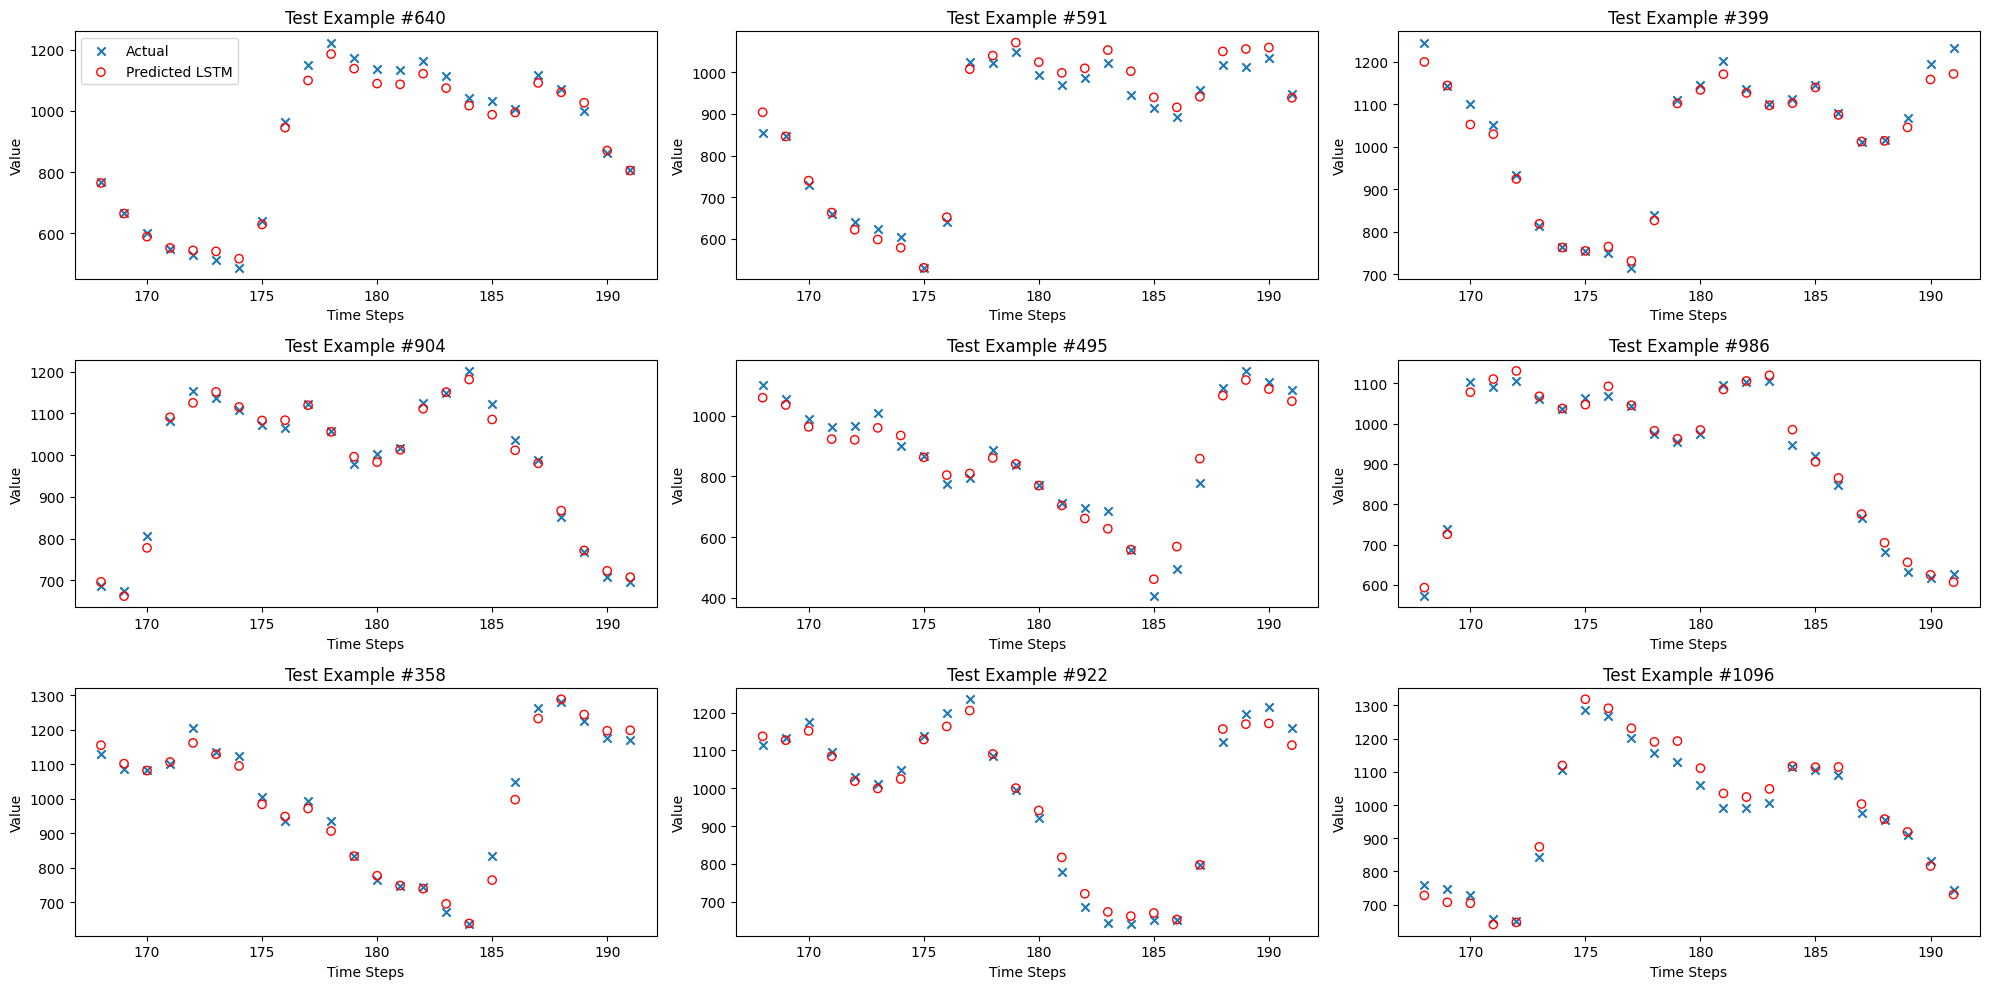

In [127]:
model_encoder_decoder_lstm.eval()

drawTestPlotsGivenModel(model_encoder_decoder_lstm, False)